## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

### Answer: The purpose of this analysis is to develop a Phase I control chart that tracks pour consistency for a pint of beer at Buster's Sports Bar & Grill. Then design a Phase II CUSUM and EWMA charts for monitoring drift

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

### Answer: The quality characteristic the team will monitor is pour volume. Pour volume is measuree in ounces and is assumed to be a continous variable and normally distributed.  Each pint of beer is targeted to be 16 ounces.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

### Answer: CUSUM and EWMA charts would be useful in this scenario because each detects gradual shifts from the mean or target. The manager states that line pressure creeps downward over time making these charts useful in this scenario.  These charts are useful at detecting gradual shifts but are less effective at detecting large sudden shifts becasue they take into account historical data.  

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [3]:
## Clone forked repository to Colab ##

## Specify your GitHub username:
user_name <- "Bishop13"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive for HW1:

setwd("STAT-7110-Quality-Control//Assignments//HW2")## Q4 Code ##

In [5]:
install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Phase I Data ##

phase1 <- read_excel("BustersSportsBar_PhaseI.xlsx")
phase2 <- read_excel("BustersSportsBar_PhaseII.xlsx")

phase_1<- as.matrix(phase1[, c("Pour1","Pour2","Pour3","Pour4","Pour5")])

dim(phase1)
dim(phase2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



[1] 25  6

[1] 20  6

In [6]:
xbar <- rowMeans(phase_1)
r    <- apply(phase_1, 1, max) - apply(phase_1, 1, min)
s    <- apply(phase_1, 1, sd)

mu_hat  <- mean(xbar)
sigma_R <- mean(r) / 2.326     # d2 for n = 5
sigma_S <- mean(s) / 0.9400    # c4 for n = 5
c(mu_hat, sigma_R, sigma_S)

[1] 16.03855840  0.07718659  0.07532471

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

### Answer: Group 19 is out of control in the Phase I $R$ chart. This subgroup would have the greatest variance of the groups causing the shift. This could be caused by a fault in the system or in the flow meter itself.

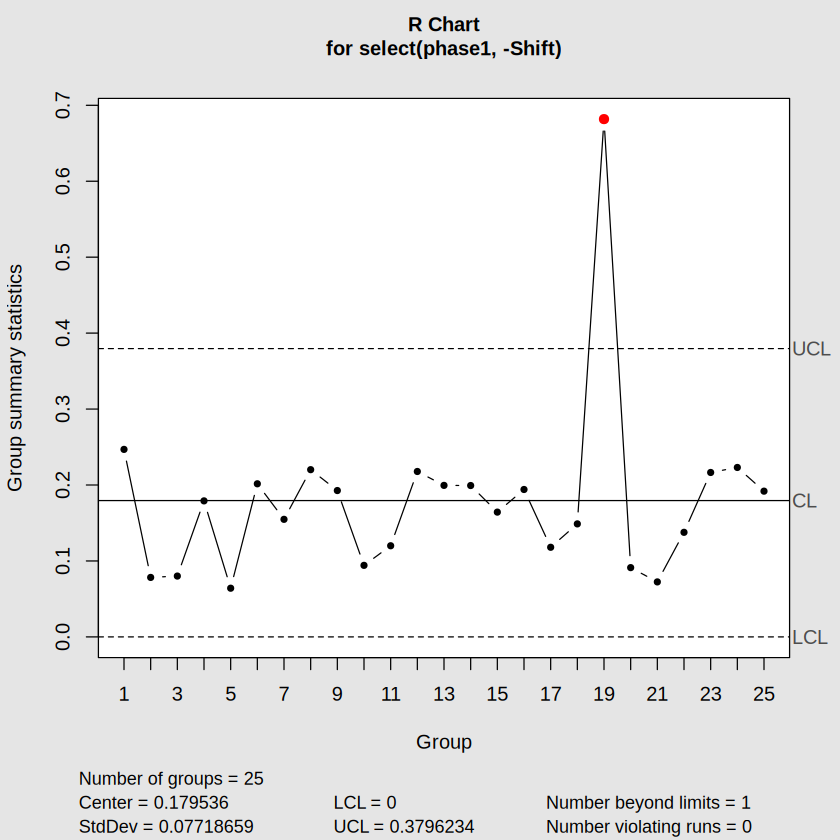

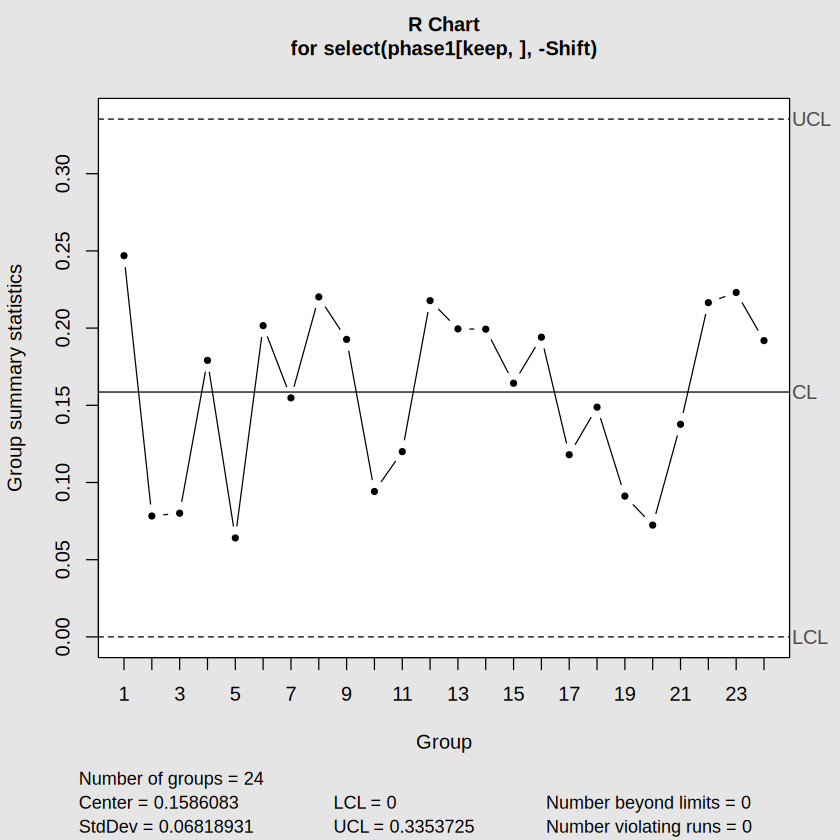

In [7]:
## Save and plot phase 1 R chart ##

phase1_rchart <- qcc(phase1 |> select(-`Shift`),
                    type = "R", plot = TRUE)

keep <-setdiff(1:25, 19)

phase1_rchart_keep <- qcc(phase1[keep, ] |> select(-`Shift`),
                    type = "R", plot = TRUE)

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

### Answer: The phase I $\bar{X}$ chart does show that group 12 is out of control. This group has the greatest shift in the mean and is below the LCL. This could be a calibration issue with the flow meter or some part of the equipment is not behaving as it should.  This would need to be investigated.

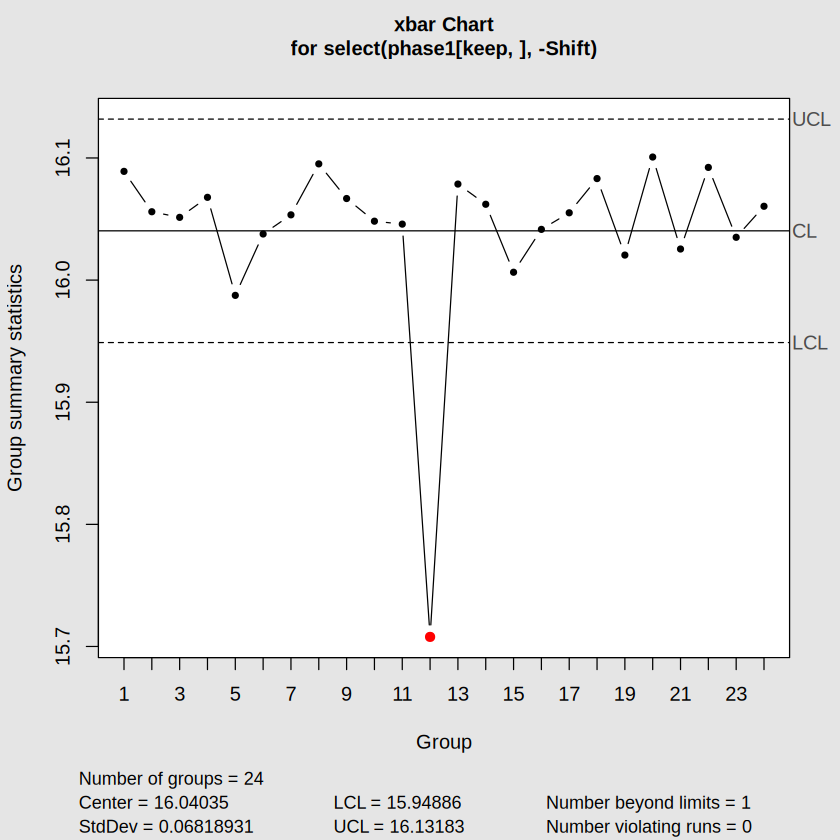

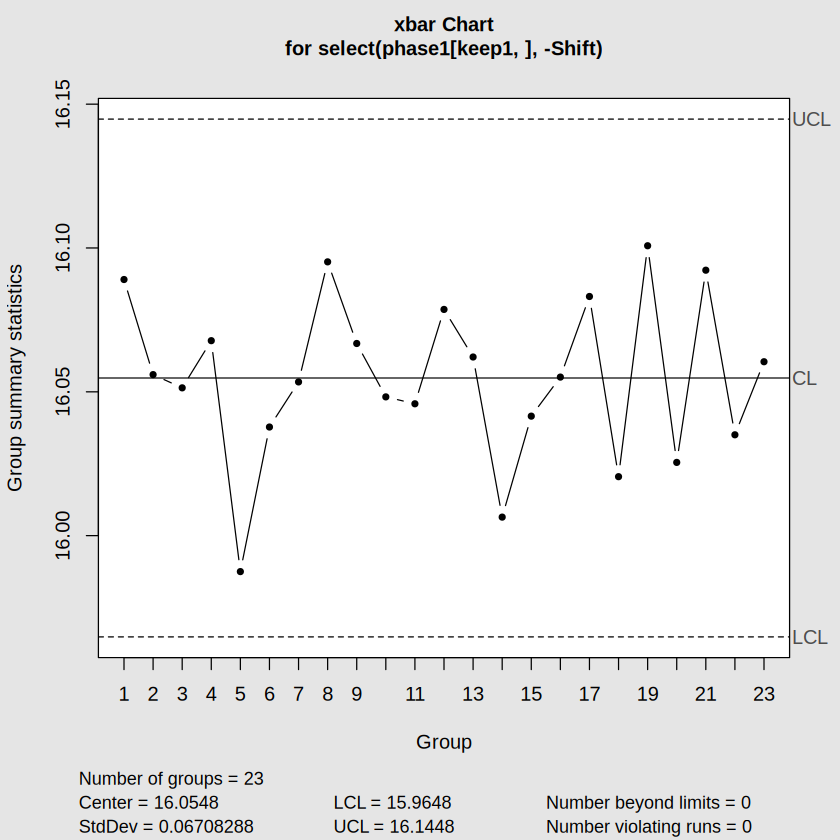

In [8]:
## Save and plot phase 1 xbar chart ##

phase1_xchart <- qcc(phase1[keep, ] |> select(-`Shift`),
                    type = "xbar", plot = TRUE)

keep1 <-setdiff(1:25, c(12, 19))

phase1_xchart_keep <- qcc(phase1[keep1, ] |> select(-`Shift`),
                    type = "xbar", plot = TRUE)

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

### Answer: Currently the process is not capable of meeting the specifications and it is not well centered. The baseline mean is not the targeted 16 ounces and is actually 16.05 ounces. Because $C_{pk} < C_p$, the problem is mostly location rather than spread.

In [9]:
clean <- phase_1[keep1, ]
mu_final    <- mean(rowMeans(clean))
sigma_final <- mean(apply(clean, 1, sd)) / .94
c(mu_final, sigma_final)


LSL <- 15.8
USL <- 16.2
target <- 16
FNC <- pnorm(LSL, mu_final, sigma_final) + (1 - pnorm(USL, mu_final, sigma_final))
Cp  <- (USL - LSL) / (6 * sigma_final)
Cpk <- min(USL - mu_final, mu_final - LSL) / (3 * sigma_final)
Cpm <- (USL - LSL) / (6 * sqrt(sigma_final^2 + (mu_final - target)^2))
round(c(FNC = FNC, Cp = Cp, Cpk = Cpk, Cpm = Cpm), 6)

[1] 16.05480261  0.06663589

FNC       Cp      Cpk      Cpm 
0.014733 1.000462 0.726322 0.772708

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

### Answer:
###(a) The slack value K = 0.5 would give us half of the shift we want to catch of $1\sigma$. With an $H$ of 5 that would give an ARL of 468 which is in the interval 370-500.
###(b)  If we choose a smoothing constant $\lambda$ of 0.10 and width value $L$ of 2.184 that would put the ARL value at 500 which is inside the in-control ARL interval. Choosing these values would help detect small gradual shifts. In this case, a flow regulator wear would creep over time and we want to dectect that gradual wear shift.

## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q8, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

### Answer: The chart does show it is out of control by breaking the LCL.  The pattern goes out of control at group 13. Before group 13 there is a pattern of non-conformance in a downward tragectory starting at group 8.

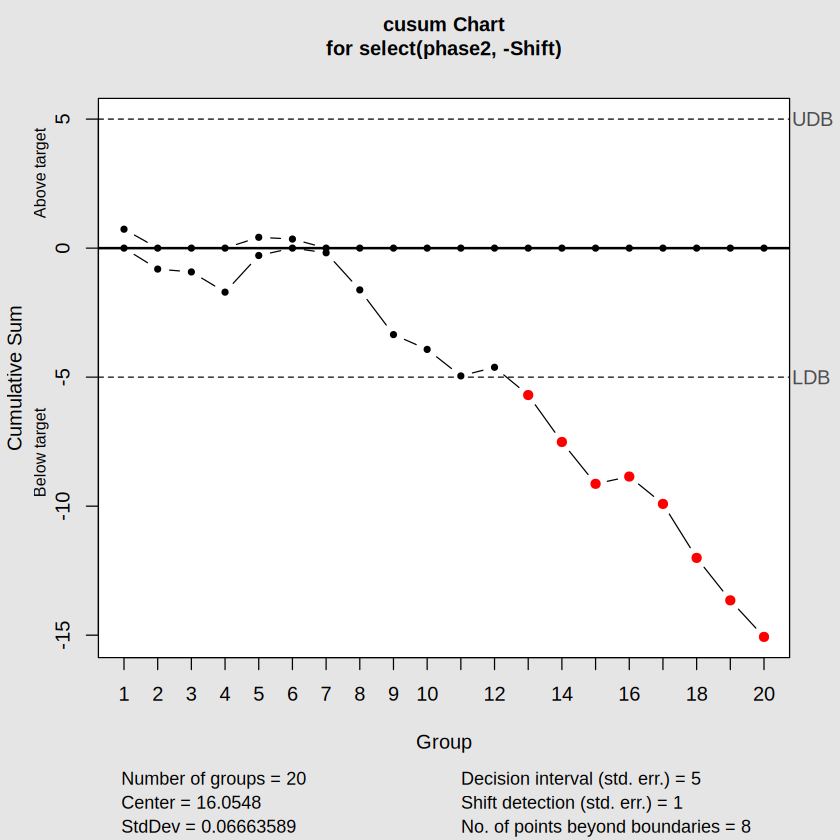

In [15]:
## Parameters from Q8 ##
k <- 0.5
h <- 5

phase2_cusum <- cusum(phase2 |> select(-Shift),
                      center = mu_final, std.dev = sigma_final,
                      se.shift = 2 * k, decision.interval = h, plot = TRUE)

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

### Answer: Yes the chart shows that it is out of control starting at group 11.  Before going below the LCL there is a pattern of non-conformance starting at group 7.

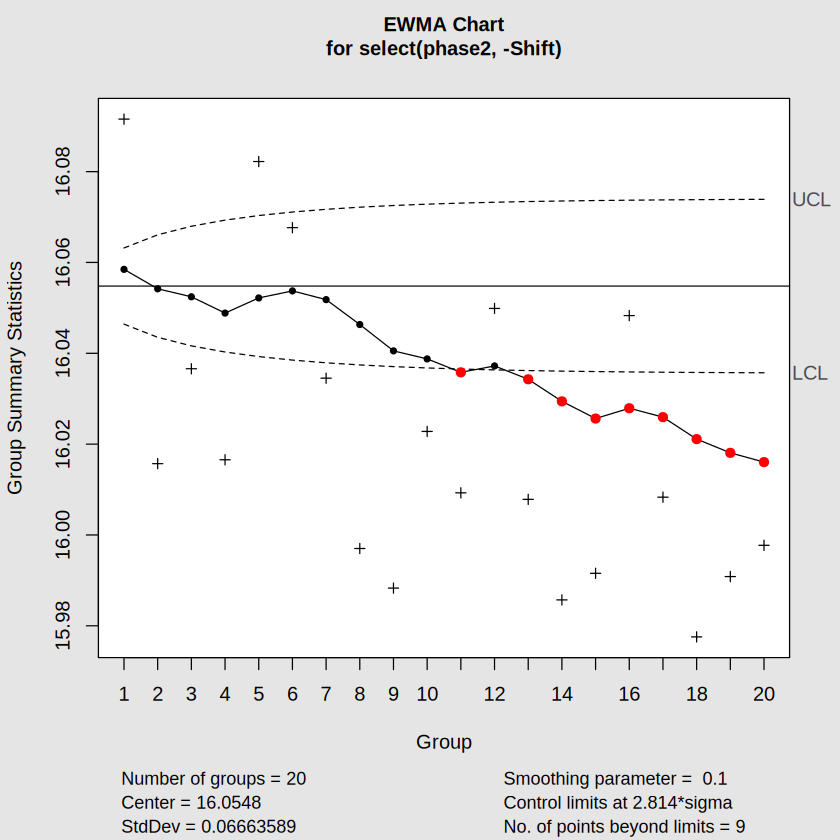

In [12]:
## Parameters from Q8 ##
lambda <- 0.10
L      <- 2.814

## EWMA chart with qcc, centered at the FINAL Phase I estimates ##
phase2_ewma <- ewma(phase2 |> select(-Shift),
                    center = mu_final, std.dev = sigma_final,
                    lambda = lambda, nsigmas = L, plot = TRUE)

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

### Answer: The EWMA chart detected the shift earlier than the CUSUM chart two groups earlier at group 11. Both charts successfully showed the downward trend starting at almost the same group. This is consistant with what we have learned so far about the behavior of the CUSUM and EWMA charts.  By choosing different values for the EWMA chart it makes it more sensitive to shifts than does the CUSUM chart.

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?

### Answer: For phase I we found two unusual shifts. After removing those two groups we were able to show the tap was stable but was pouring approximately 16.05 ounces instead of the target of 16 ounces. Once we stabalized the Phase I chart we moved into phase II. Phase II showed a downward pattern of non-conformance and eventually the process went out of control breaking the lower control limit set. The downware shift is actually getting closer to the target value of 16 ounces.  Even though it is getting closer to the target value the pours are still consistantly showing the downward trajectory. My recommendation is the regulator should be replaced sooner rather than later. AFter the regulator is replaced start a fresh phase I with the target of 16 ounces.  Then create new phase II charts to be aware of any new trends in the future.